# Sephora E-Commerce EDA: 03 - Review & Reviewer Profile Deep Dive

This notebook focuses on the review-level data (~1.1M records). We inspect reviews volume over time (seasonality), reviewer demographics (skin profile, hair color), and factors influencing review helpfulness.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_reviews
from src.viz_utils import set_custom_style

set_custom_style()
reviews_df = load_reviews("../data", include_text=False)

Custom plotting style and palettes configured successfully.
Found 5 review files. Loading sequentially...
Reviews shape: (1094411, 13)
Memory: 446.44 MB -> 96.48 MB (Saved: 78.4%)


Reading reviews CSVs: 100%|##########| 5/5 [00:04<00:00,  1.06it/s]


## 1. Reviews Volume Over Time

Let's see if there is any holiday season spikes (e.g. November/December) in Sephora's reviews volume.

<string>:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


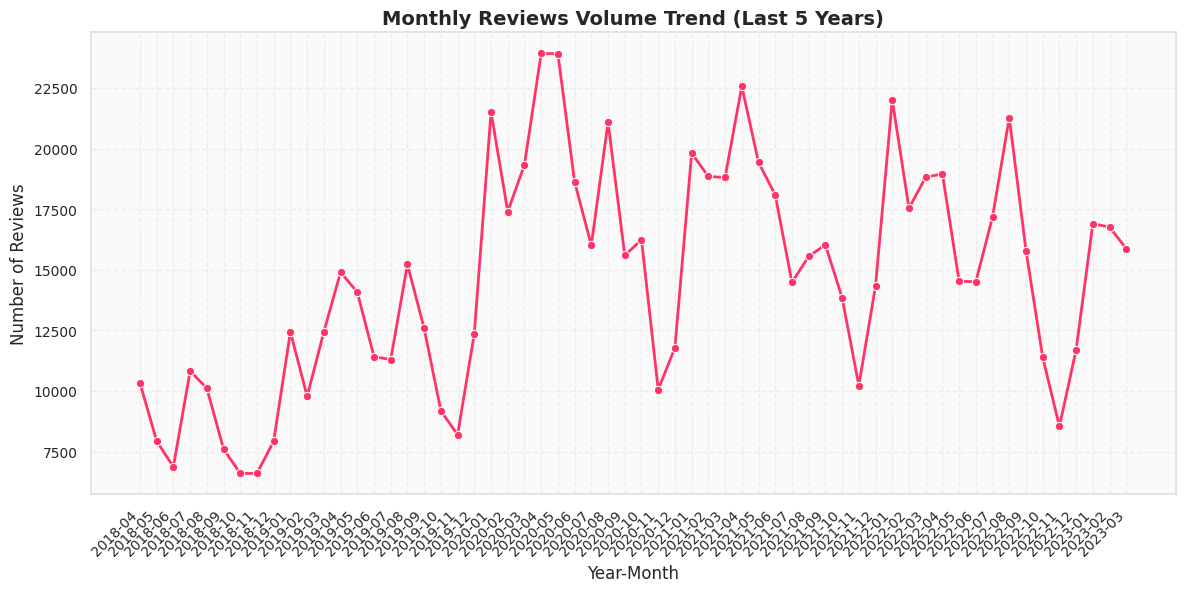

In [2]:
reviews_df["year_month"] = reviews_df["submission_time"].dt.to_period("M")
monthly_reviews = reviews_df.groupby("year_month").size().reset_index(name="count")
monthly_reviews["year_month"] = monthly_reviews["year_month"].astype(str)

# Line plot showing review count trends over the last 5 years
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_reviews.tail(60), x="year_month", y="count", marker="o", color="#FF3366", linewidth=2)
plt.title("Monthly Reviews Volume Trend (Last 5 Years)", fontsize=14, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Year-Month")
plt.ylabel("Number of Reviews")
plt.show()

## 2. Reviewer Demographic Profiles

Sephora reviews contain customer profiles like skin type, skin tone, hair color, and eye color. Let's analyze who is buying and reviewing these cosmetics.

<string>:8: FutureWarning: 
Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.
<string>:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


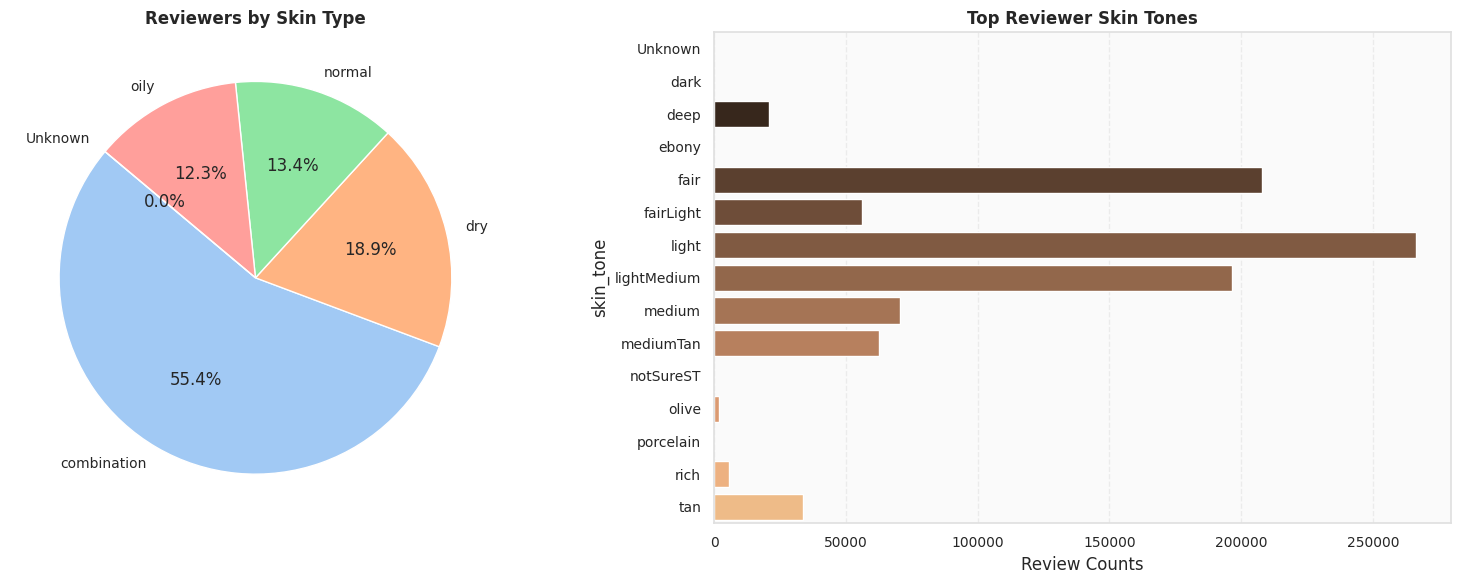

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

skin_type_counts = reviews_df[reviews_df["skin_type"] != "Unknown"]["skin_type"].value_counts()
axes[0].pie(skin_type_counts, labels=skin_type_counts.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"), startangle=140)
axes[0].set_title("Reviewers by Skin Type", fontsize=12, weight="bold")

skin_tone_counts = reviews_df[reviews_df["skin_tone"] != "Unknown"]["skin_tone"].value_counts().head(10)
sns.barplot(x=skin_tone_counts.values, y=skin_tone_counts.index, ax=axes[1], palette="copper")
axes[1].set_title("Top Reviewer Skin Tones", fontsize=12, weight="bold")
axes[1].set_xlabel("Review Counts")
plt.tight_layout()
plt.show()

## 3. Review Helpfulness Analysis

What makes a review helpful? Let's check the helpfulness score (which is a ratio of positive feedback to total feedback) across ratings.

<string>:3: FutureWarning: 
Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.
<string>:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


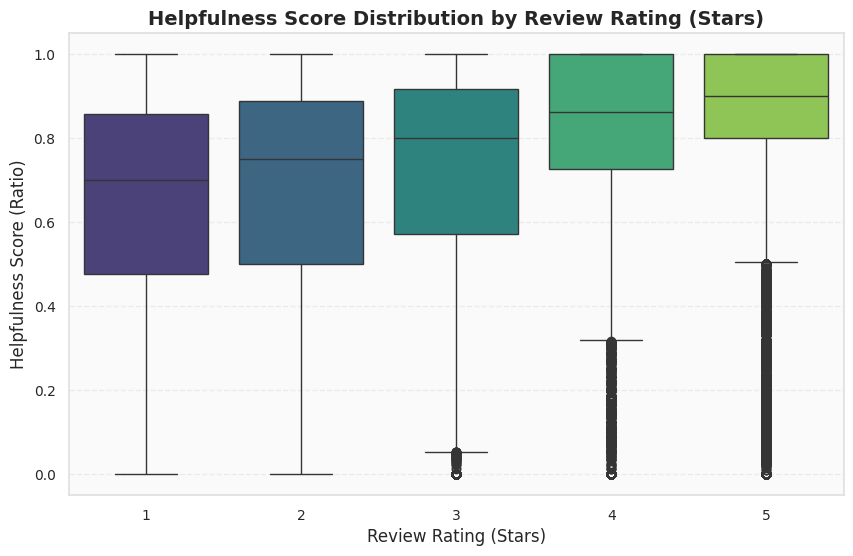

In [4]:
plt.figure(figsize=(10, 6))
# Minimum 5 feedback votes to avoid ratio skewness (like 1/1 being 100% helpful)
sns.boxplot(data=reviews_df[reviews_df["total_feedback_count"] >= 5], x="rating", y="helpfulness", palette="viridis")
plt.title("Helpfulness Score Distribution by Review Rating (Stars)", fontsize=14, weight="bold")
plt.xlabel("Review Rating (Stars)")
plt.ylabel("Helpfulness Score (Ratio)")
plt.show()